In [15]:
import sys
import os
from collections import namedtuple
from pathlib import Path
import json
import datetime
import pprint

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io

from tqdm.notebook import tqdm

import torch
import torch.nn as tnn
import torch.nn.functional as tnnf
import torch.optim as topt
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

sys.path.append('..')
from lib.utils import *
from lib.logging import *

# Setup

In [16]:
project_root_path = ! git rev-parse --show-toplevel
project_root_path = Path(project_root_path[0])

LOG = Logging()
RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 'project_root_path, data_path, metrics_path, model_path, notebook_fname, notebook_name, is_cuda, cuda_device')(
    project_root_path=project_root_path,
    data_path=project_root_path / 'data' / 'sparsenet',
    metrics_path=project_root_path / 'tensorboard',
    model_path=Path('.') / 'model',
    notebook_fname='noname.ipynb',
    notebook_name='noname',
    is_cuda=torch.cuda.is_available(),
    cuda_device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_fname = os.path.basename(notebook_fname)
    CONFIG = CONFIG._replace(notebook_fname=notebook_fname, notebook_name=os.path.splitext(notebook_fname)[0])

pprint.pprint(CONFIG._asdict())

{'cuda_device': device(type='cuda'),
 'data_path': PosixPath('/home/misha/dev/mine/neurovision/data/sparsenet'),
 'is_cuda': True,
 'metrics_path': PosixPath('/home/misha/dev/mine/neurovision/tensorboard'),
 'model_path': PosixPath('model'),
 'notebook_fname': 's2_denoising_ae_01.ipynb',
 'notebook_name': 's2_denoising_ae_01',
 'project_root_path': PosixPath('/home/misha/dev/mine/neurovision')}


# Hypers

In [17]:
HP = namedtuple('HyperParameters', 'dataset_size patch_size noise filters_count batch_size epochs_count learn_rate', defaults=[None] * 7)()

# Images

In [18]:
def add_images_to_lib(images, tag):
    IMAGES_LIB[tag] = dict(images=images, image_stds=images.reshape(images.shape[0], -1).std(axis=1))

In [19]:
IMAGES_LIB = {
    'RAW': dict(fname='IMAGES_RAW.mat', mat_name='IMAGESr'),
    'WHITENED': dict(fname='IMAGES.mat', mat_name='IMAGES'),
}

for k in IMAGES_LIB:
    fname = IMAGES_LIB[k]['fname']
    mat_name = IMAGES_LIB[k]['mat_name']
    mat = scipy.io.loadmat(CONFIG.data_path / fname)
    images = mat[mat_name]
    images = np.moveaxis(images, [2], [0])
    add_images_to_lib(images, k)

# Patching

In [20]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(images, patch_size, image_ind=None, image_stds=None, rng=None):
    blind_area = 4
    trials = 1000
    rng = RNG if rng is None else rng
    image_ind = rng.choice(len(images)) if image_ind is None else image_ind
    image = images[image_ind]

    with_std = not image_stds is None
    
    if with_std:
        image_std_thres = image_stds[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + rng.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + rng.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + patch_size, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres:
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

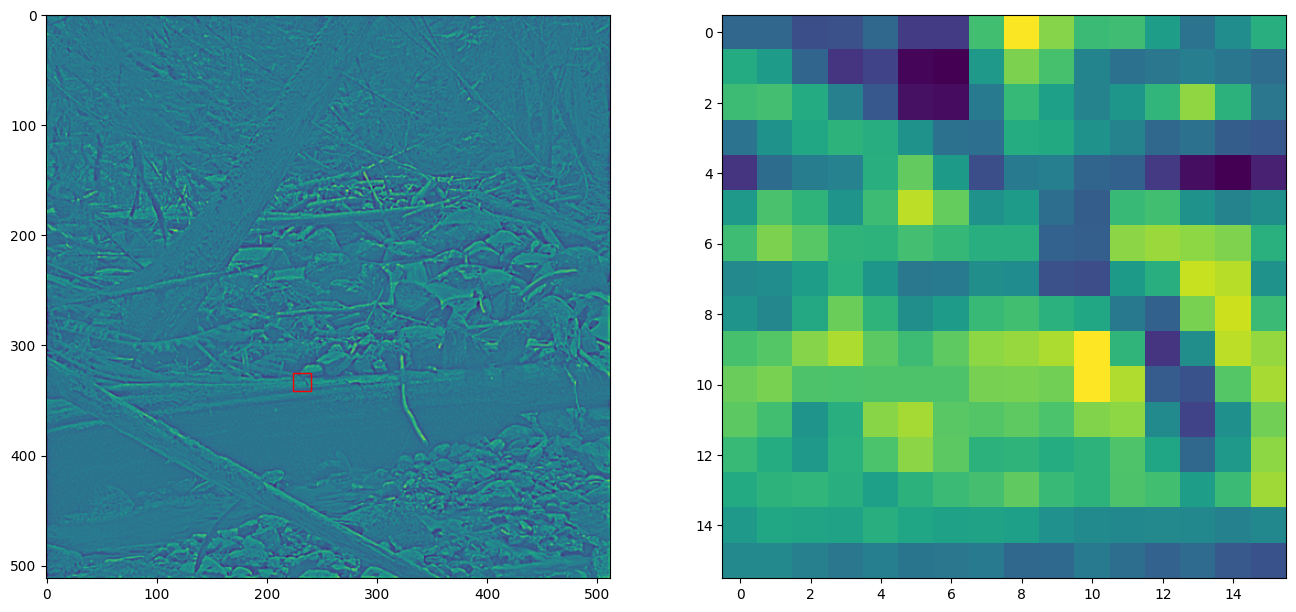

In [21]:
# slot = IMAGES_LIB['RAW']
slot = IMAGES_LIB['WHITENED']
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.imshow(images[image_ind]);
rect = pltpatches.Rectangle((j_off, i_off), patch.shape[1], patch.shape[0], linewidth=1, edgecolor='r', facecolor='none')
ax1.add_patch(rect)
ax2.imshow(patch);

# Noising

In [22]:
def gauss_noise(patch, σ, rng=None):
    save_shape = patch.shape
    patch = patch.ravel()
    rng = RNG if rng is None else rng
    result = patch + rng.normal(0, σ, len(patch))
    # result = rng.multivariate_normal(patch, σ * np.eye(len(patch)))
    return result.reshape(save_shape)

def masking_noise(patch, ν, rng=None):
    assert 0 <= ν <= 1
    save_shape = patch.shape
    patch = patch.ravel()
    rng = RNG if rng is None else rng
    inds = rng.choice(len(patch), int(ν * len(patch)), replace=False)
    result = patch.copy()
    result[inds] = 0
    return result.reshape(save_shape)

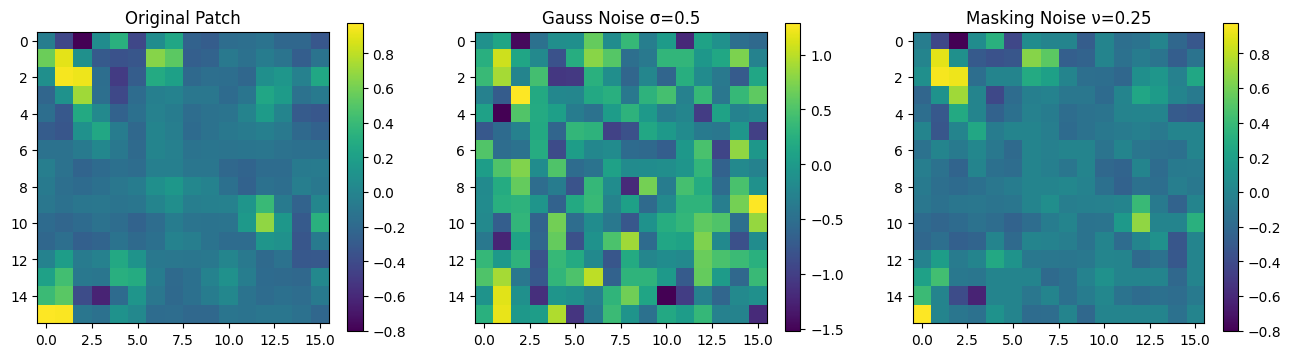

In [23]:
# slot = IMAGES_LIB['RAW']
slot = IMAGES_LIB['WHITENED']
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.set_title('Original Patch')
im = ax1.imshow(patch);
fig.colorbar(im, ax=ax1, shrink=.5)
σ = 0.5
ax2.set_title(f'Gauss Noise σ={σ}')
im = ax2.imshow(gauss_noise(patch, σ));
fig.colorbar(im, ax=ax2, shrink=.5)
ν = 0.25
ax3.set_title(f'Masking Noise ν={ν}')
im = ax3.imshow(masking_noise(patch, ν));
fig.colorbar(im, ax=ax3, shrink=.5);

# Dataset

In [42]:
dataset_rng = np.random.default_rng(82)
noisings = {
    'Gauss_0.5': lambda p: gauss_noise(p, σ=0.5, rng=dataset_rng),
    'Masking_0.1': lambda p: masking_noise(p, ν=0.1, rng=dataset_rng),
    'Masking_0.25': lambda p: masking_noise(p, ν=0.25, rng=dataset_rng),
}
HP = HP._replace(
    dataset_size=1_000_000,
    patch_size=12,
    noise='Masking_0.25',
)

In [25]:
images = IMAGES_LIB['WHITENED']['images']
dataset = []
noise_func = noisings[HP.noise]

for i in tqdm(range(HP.dataset_size)):
    patch = extract_image_patch(images, HP.patch_size, rng=dataset_rng).patch
    noised_patch = noise_func(patch)
    dataset.append((noised_patch.ravel(), patch.ravel())) # X (noised) and Y (clean)

dataset = torch.Tensor(np.array(dataset))

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [26]:
# %%timeit
# dataLoader = DataLoader(dataset, batch_size=100)

# for batch in dataLoader:
#     pass

# Model

In [27]:
class DenoiseAutoencoder(tnn.Module):
    def __init__(self, inp_dims_count, hiddens_count):
        super().__init__()
        self.filters = tnn.Linear(inp_dims_count, hiddens_count)
        self.decoder = tnn.Linear(hiddens_count, inp_dims_count)

        bound = 1 / np.sqrt(inp_dims_count)
        self.filters.weight.data.uniform_(-bound, bound)
        bound = 1 / np.sqrt(hiddens_count)
        self.decoder.weight.data.uniform_(-bound, bound)

    def forward(self, inp):
        out = tnnf.sigmoid(self.filters(inp))
        out = self.decoder(out)
        return out

In [28]:
model = DenoiseAutoencoder(144, 200)
sum([p.numel() for p in model.parameters()])

57944

In [29]:
data_loader = DataLoader(dataset, batch_size=100)
model(next(iter(data_loader))[:,0,...]).shape

torch.Size([100, 144])

# Training

We trained both regular autoencoders and denoising autoencoders on 12×12 patches from whitened natural scene images, made available by Olshausen (Olshausen and Field, 1996)... 

For these natural image patches, we used a linear decoder and a squared reconstruction cost. Network parameters were trained from a random start, using stochastic gradient descent to perform 500000 weight updates with a fixed learning rate of 0.05. All filters shown were from experiments with tied weights, but untied weights yielded similar results.

We then trained 200 hidden units over-complete noiseless autoencoders regularized with L2 weight decay, as well as 200 hidden units denoising autoencoders with isotropic Gaussian noise (but no weight decay). ... With a sufficiently large noise level however (σ = 0.5), the denoising autoencoder learns Gabor-like local oriented edge detectors 

In [31]:
HP = HP._replace(
    filters_count=200,
    batch_size=10_000,
    epochs_count=1_000,
    learn_rate=0.05
)
pprint.pprint(HP._asdict())

{'batch_size': 10000,
 'dataset_size': 1000000,
 'epochs_count': 1000,
 'filters_count': 200,
 'learn_rate': 0.05,
 'noise': NoiseType(mnem='Masking_0.25', func=<function <lambda> at 0x7db3c874e5c0>),
 'patch_size': 12}


In [32]:
data_loader = DataLoader(dataset, batch_size=HP.batch_size, pin_memory=CONFIG.is_cuda, shuffle=True)
model = DenoiseAutoencoder(HP.patch_size**2, HP.filters_count).to(device=CONFIG.cuda_device)
optimizer = topt.Adam(model.parameters(), lr=HP.learn_rate)
loss_fn = tnn.MSELoss()

In [34]:
metrics_dir = CONFIG.metrics_path / CONFIG.notebook_name / datetime.datetime.now().strftime('%y-%m-%dT%H:%M:%S')
metrics_writer = SummaryWriter(log_dir=metrics_dir)

for epoch in tqdm(range(HP.epochs_count)):
    loss_train = 0
    
    for batch in data_loader:
        optimizer.zero_grad()
        
        noised_data = batch[:,0,...].to(device=CONFIG.cuda_device)
        true_data = batch[:,1,...].to(device=CONFIG.cuda_device)
        infer_data = model(noised_data)
        loss = loss_fn(infer_data, true_data)
        loss.backward()
        
        optimizer.step()
        
        loss_train += loss.item()
    
    metrics_writer.add_scalar('loss', loss_train / len(data_loader), epoch)
    metrics_writer.flush()

  0%|          | 0/1000 [00:00<?, ?it/s]

In [45]:
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'hypers': HP._asdict(),
}, CONFIG.model_path / f'{CONFIG.notebook_name}_{datetime.datetime.now().strftime('%y-%m-%dT%H:%M:%S')}.pt')

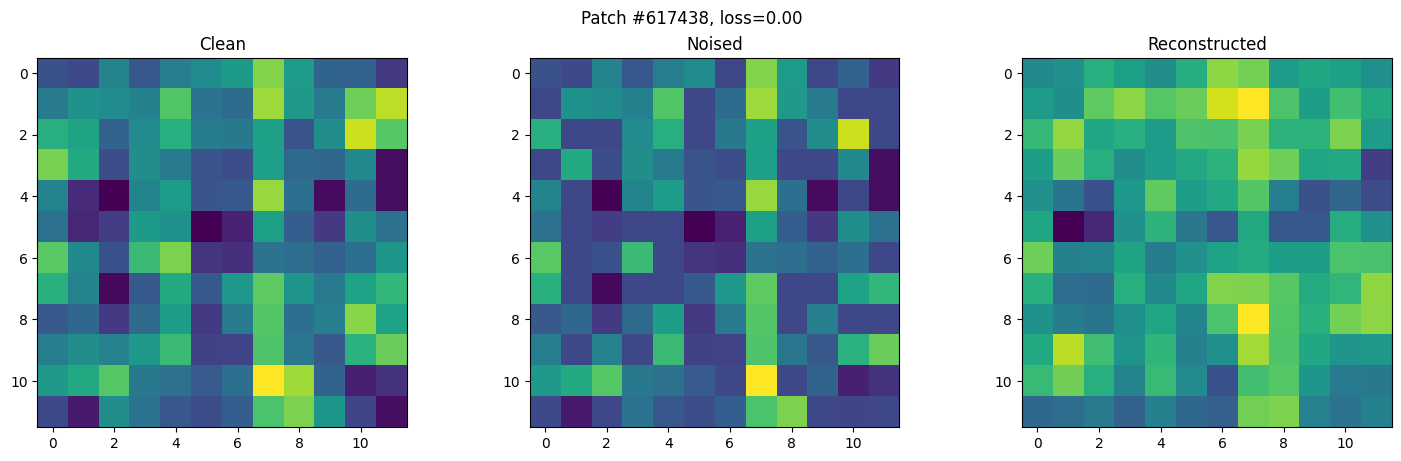

In [59]:
# ind = RNG.choice(len(dataset))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(18)

noised = dataset[ind,0,:]
clean = dataset[ind,1,:]
reconstructed = model(noised.reshape(1, 1, -1).to(CONFIG.cuda_device)).to(device='cpu').detach().ravel()

ax1.set_title('Clean')
ax1.imshow(vec_to_square_matrix(clean))

ax2.set_title('Noised')
ax2.imshow(vec_to_square_matrix(noised))

ax3.set_title('Reconstructed')
ax3.imshow(vec_to_square_matrix(reconstructed));

plt.suptitle(f'Patch #{ind}, loss={loss_fn(reconstructed, clean):.2f}');

In [54]:
((clean - reconstructed)**2).sum()

tensor(0.0696)

In [66]:
np.round(dataset[:,0,:].std(axis=0), 2)

tensor([0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400, 0.2400,
        0.2400, 0.2400, 0.2400, 0.2400, 

In [60]:
clean[:12], reconstructed[:12]

(tensor([ 0.0032,  0.0007,  0.0243,  0.0064,  0.0219,  0.0283,  0.0344,  0.0623,
          0.0349,  0.0113,  0.0105, -0.0049]),
 tensor([0.0021, 0.0057, 0.0234, 0.0148, 0.0044, 0.0231, 0.0533, 0.0478, 0.0122,
         0.0188, 0.0152, 0.0055]))

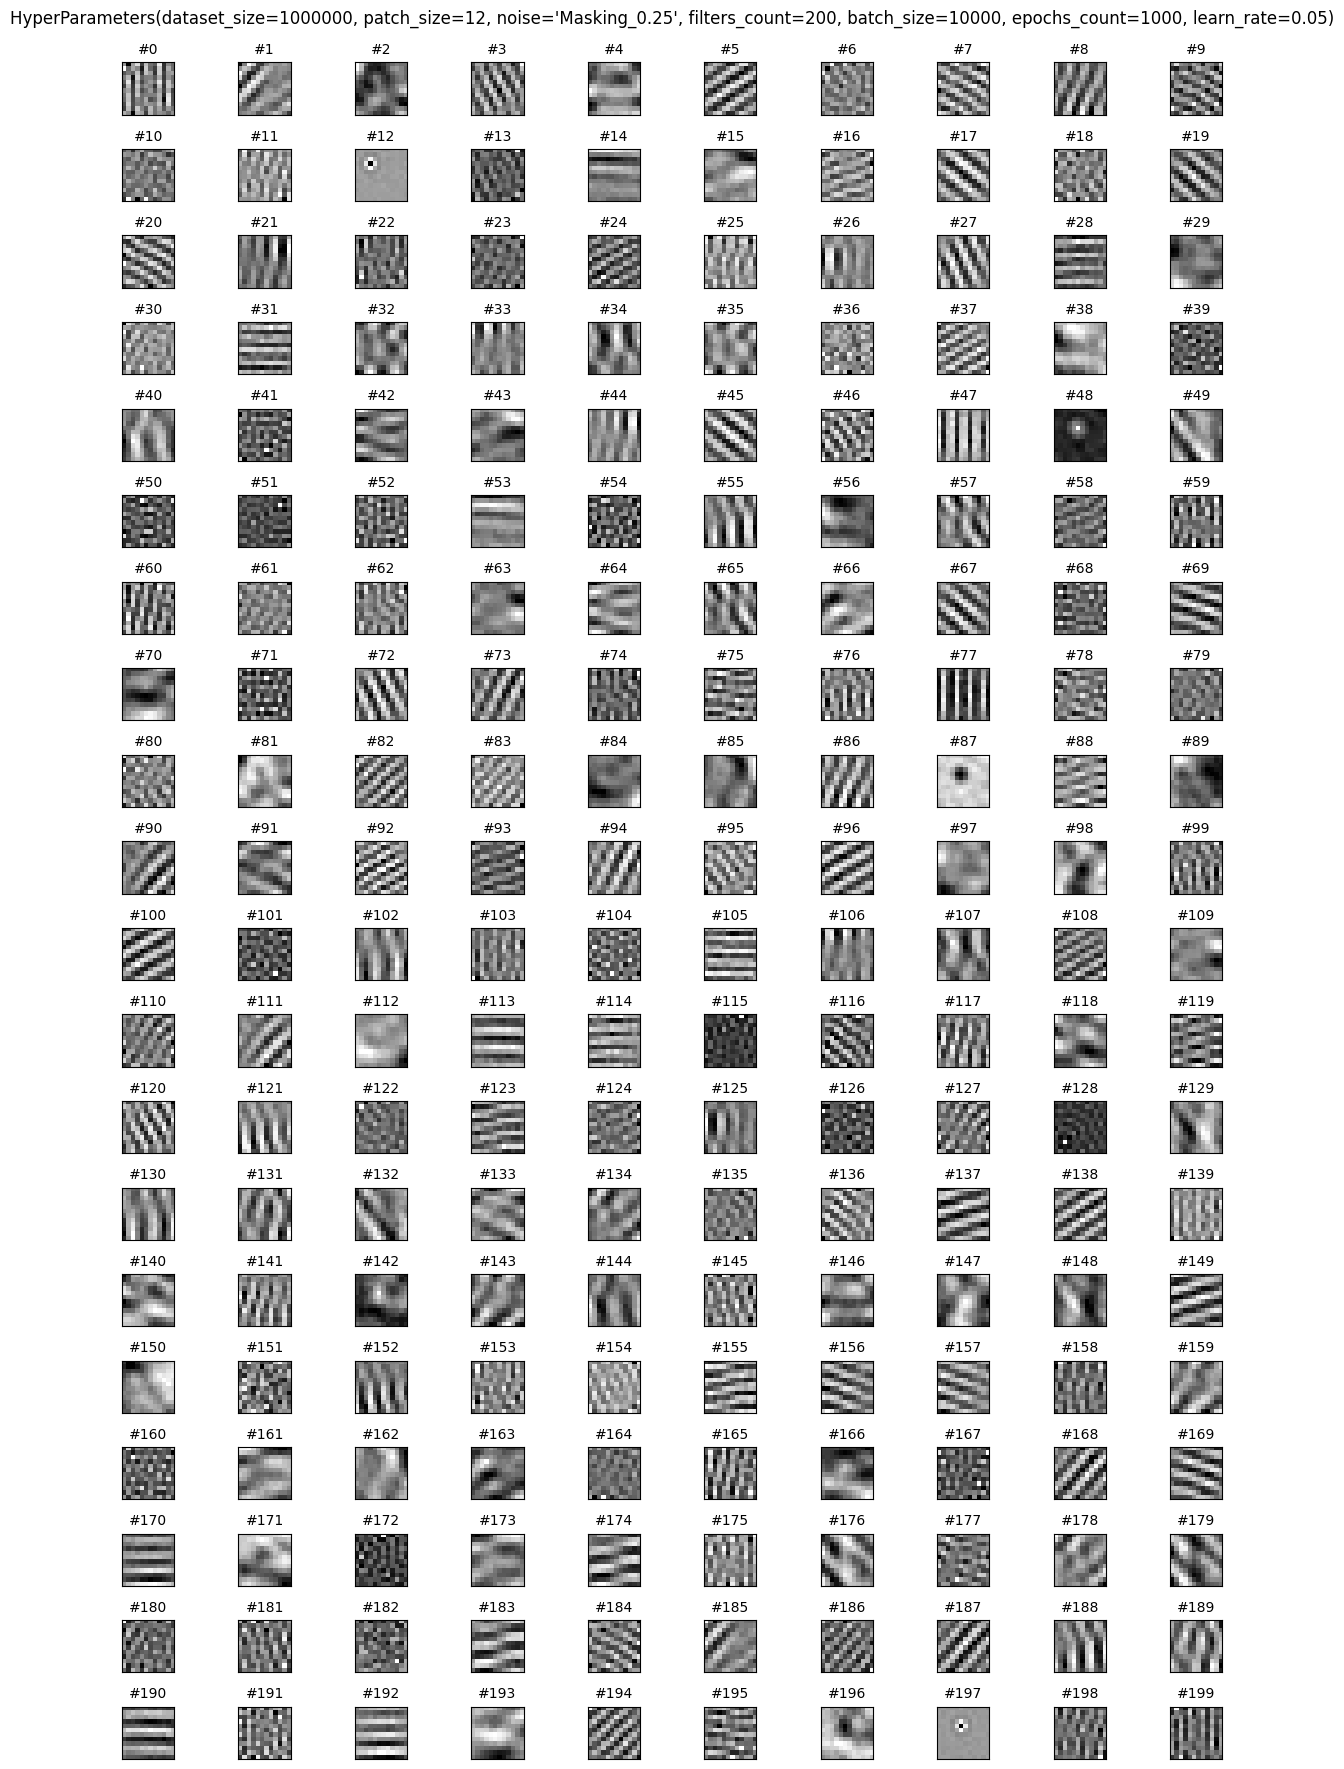

In [69]:
bases_in_row = 10
fig, axes = plt.subplots(int(np.ceil(HP.filters_count / bases_in_row)), bases_in_row)
fig.set_figwidth(12)
fig.set_figheight(18)
filters = model.filters.weight.to(device='cpu').detach()

for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(vec_to_square_matrix(f), cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(pprint.pformat(HP) + '\n')
plt.tight_layout()

# Results

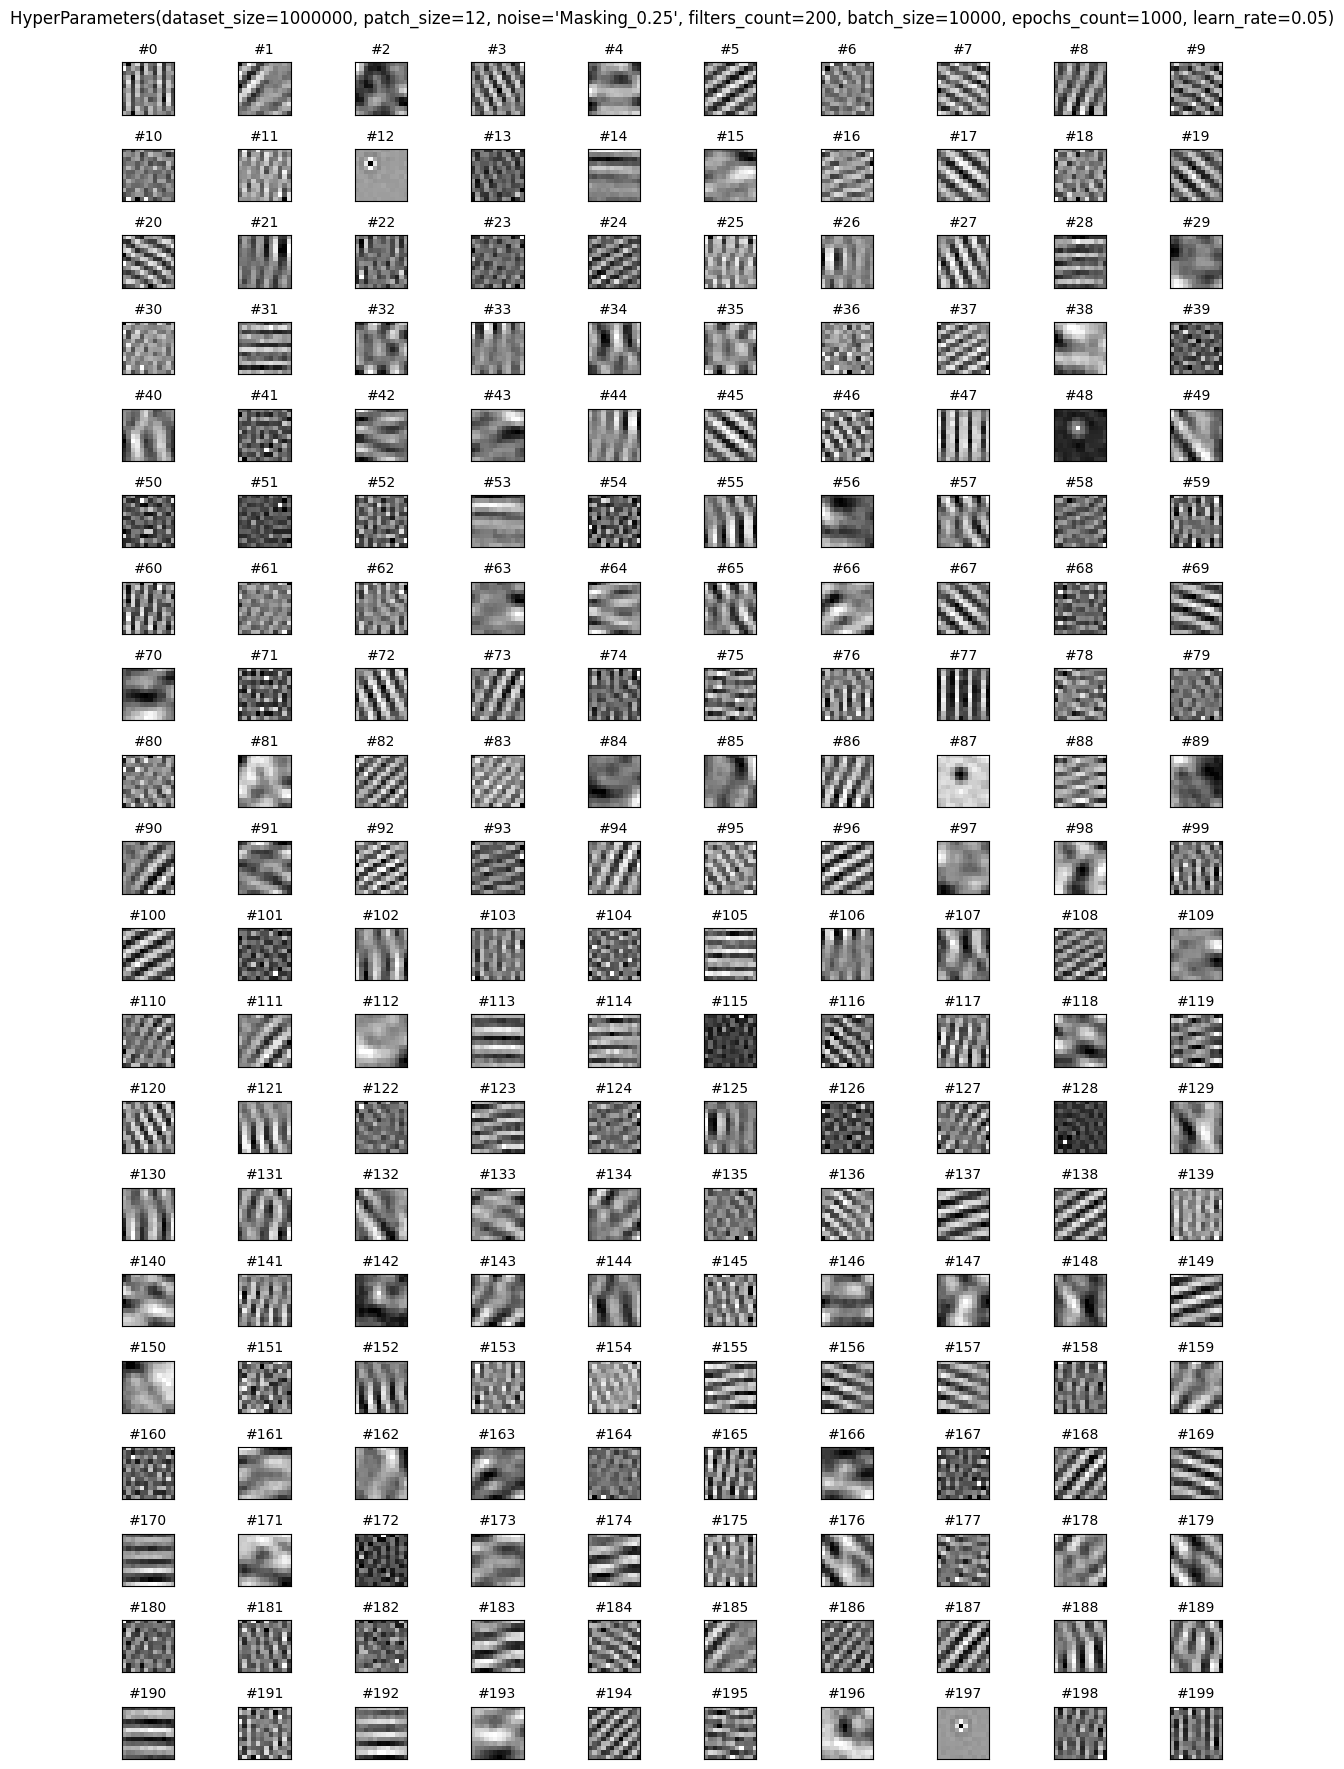

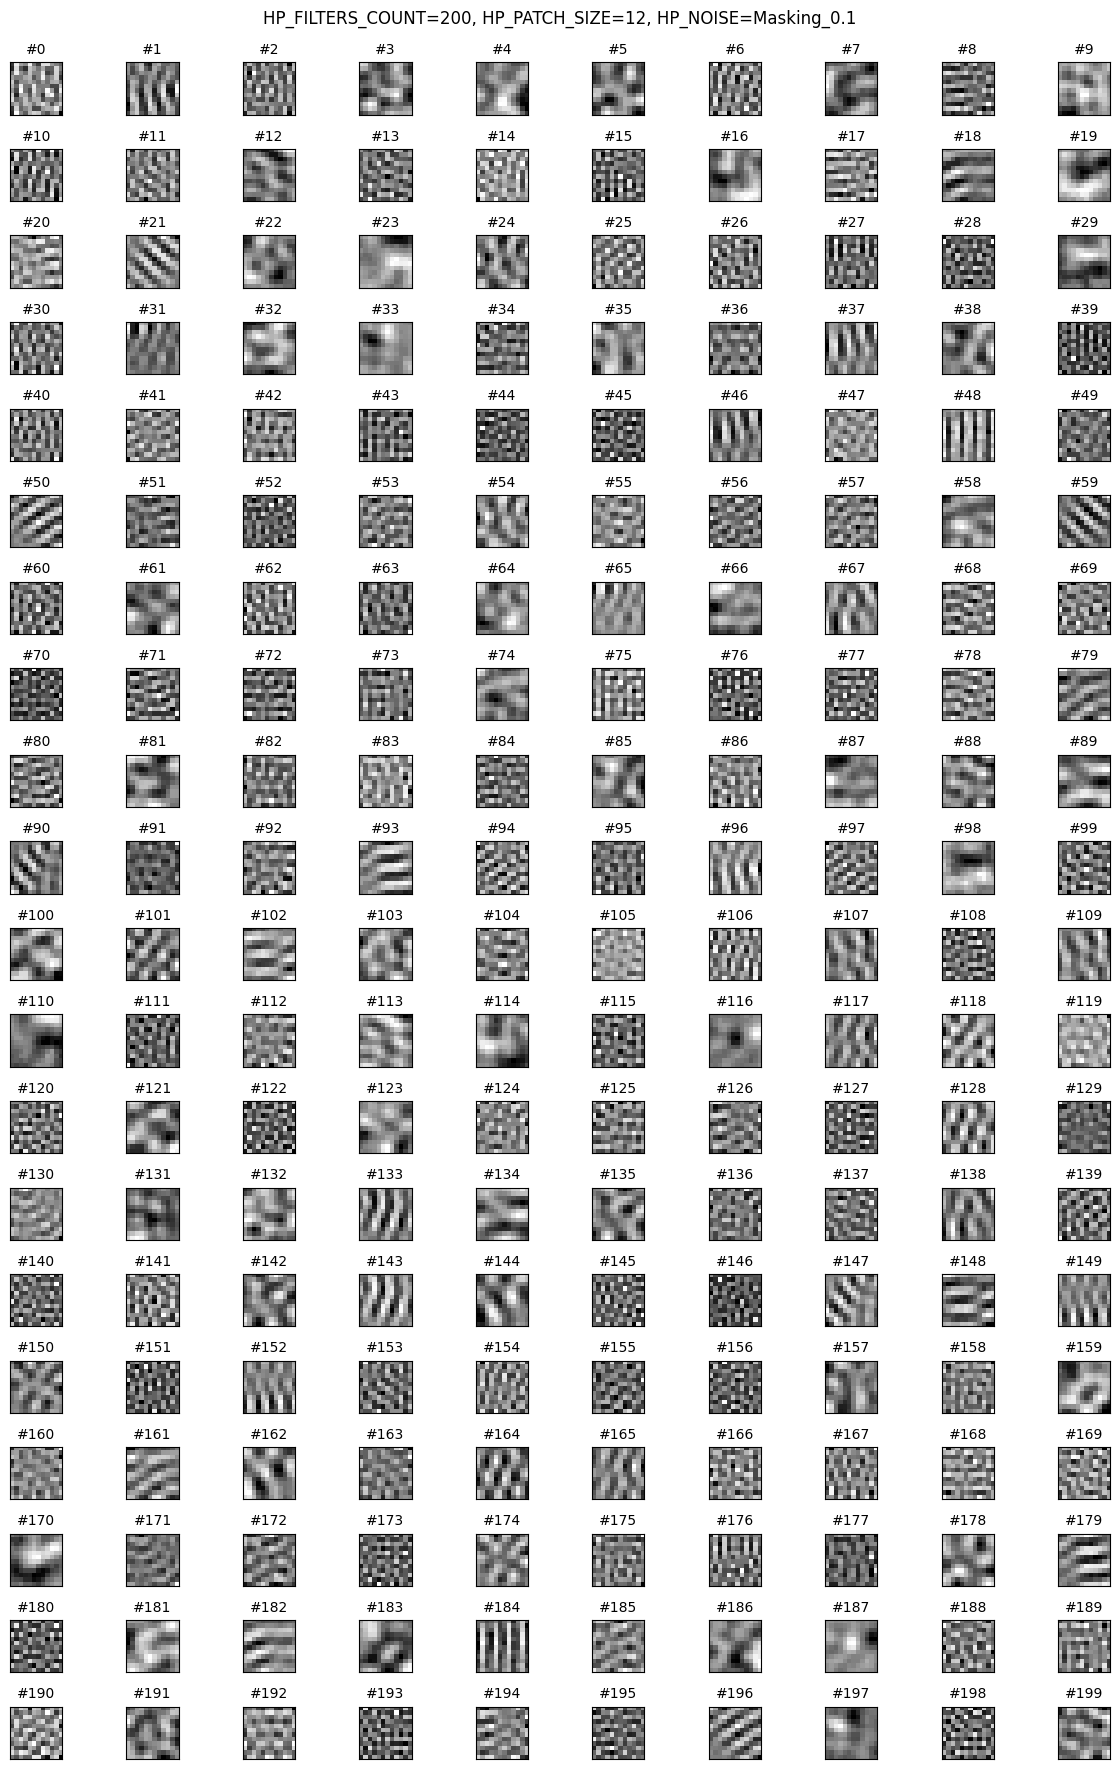

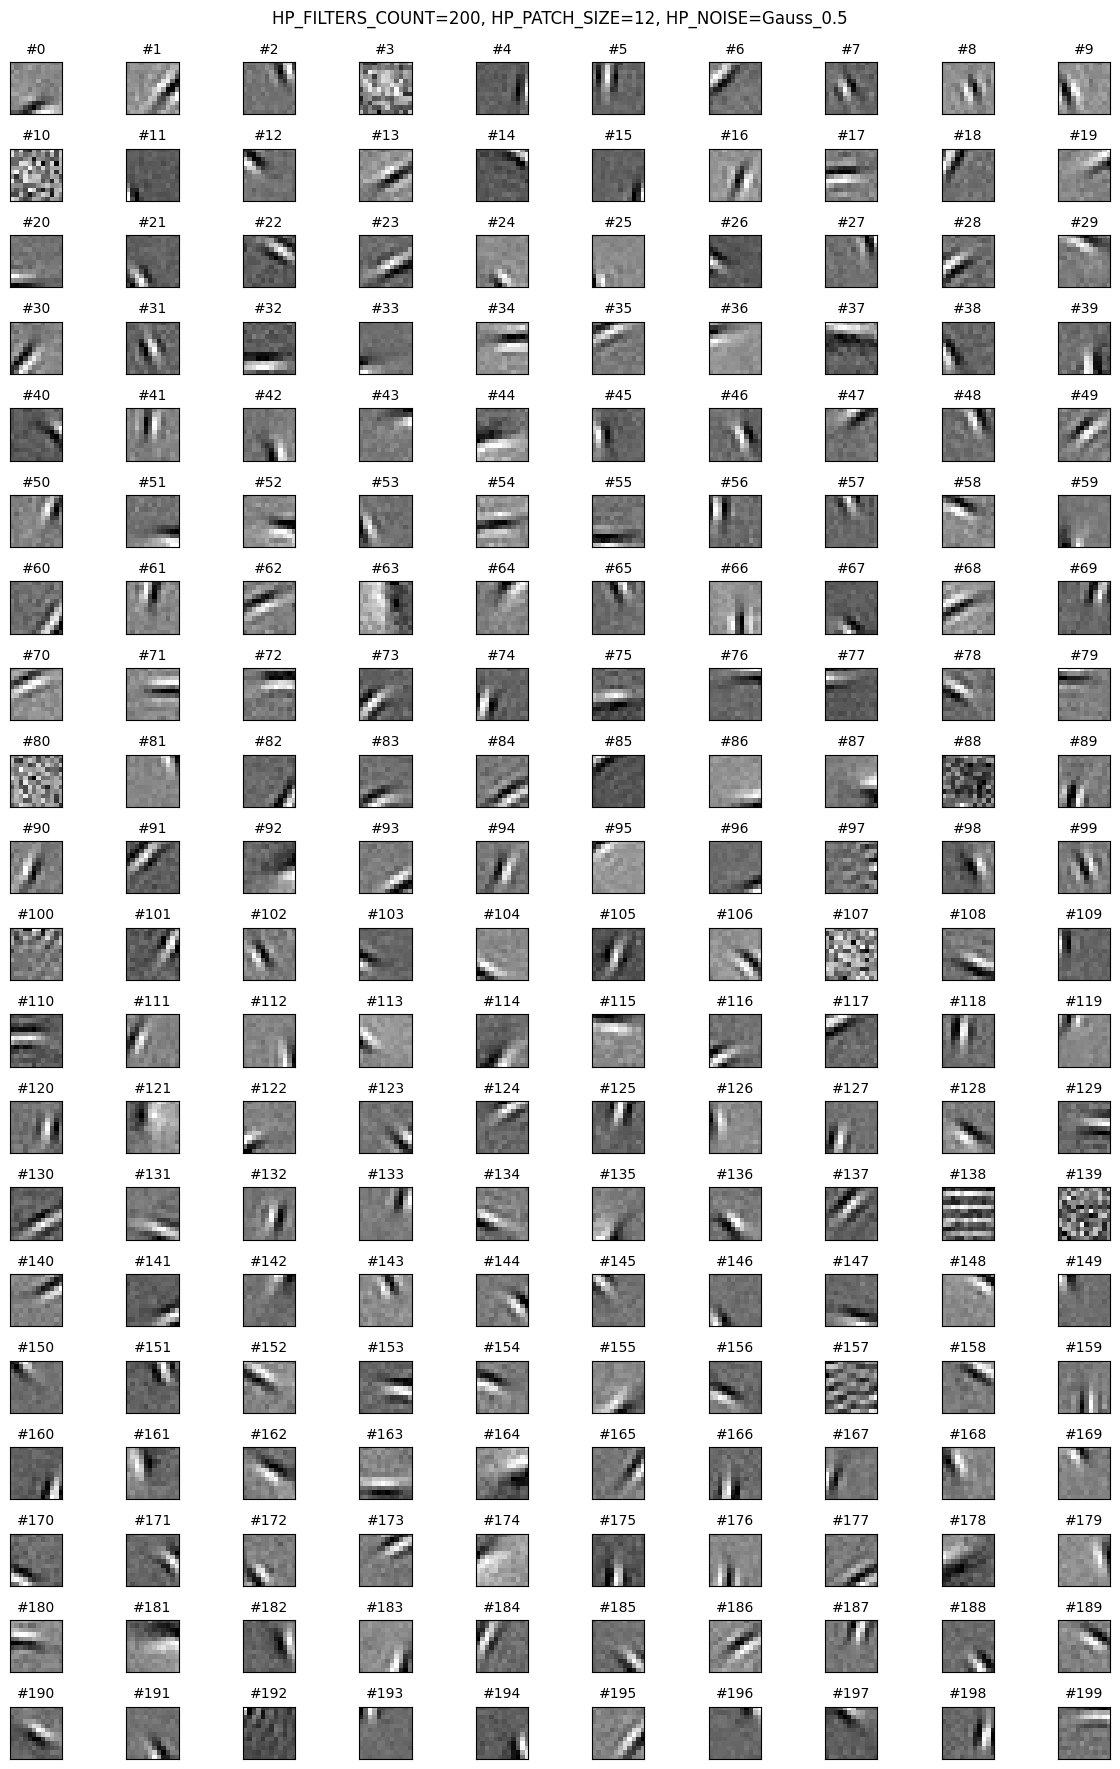